# Session 04 — Fine-tuning a pretrained model

In Session 03, we trained a tiny Transformer from scratch. This time we start with DistilBERT, which has already learned from a large text corpus, and adapt it to predict a YouTube video's category from its title and description.

We will compare three ways to use the **same pretrained model and data**: update every parameter, update only the classification head, and train a small LoRA adapter. The optional final exercise shows the Hugging Face Trainer API.


## Learning objectives

By the end of the lab, you should be able to:

- explain how an encoder is pretrained with masked language modelling;
- distinguish the pretrained body from the new classification head;
- run and inspect a fine-tuning loop;
- freeze and count parameters;
- explain the two small matrices in LoRA;
- compare methods using validation accuracy, trainable parameters, and elapsed time.

A GPU is recommended. On CPU, the notebook uses fewer examples and shorter inputs. Start in this folder so the included data files are found. On Colab, upload both data files before running the notebook.


## 0. From pretraining to fine-tuning

### 0.1 Encoders vs decoders

In Session 02, we built a **decoder-only** Transformer: a causal mask lets each token attend only to the tokens on its left, and pretraining means predicting the **next token**. That is the recipe behind GPT-style models, which generate text from left to right.

DistilBERT is an **encoder-only** model. It has no causal mask: every token attends to every other token, on both sides. It turns each input token into a contextual vector that depends on the whole sentence. Next-token prediction would be trivial here, since the model could simply look at the next token, so encoders are pretrained with a different objective.

**Masked language modelling (MLM)**: hide some tokens (about 15% in BERT) behind a special `[MASK]` token and train the model to recover them from the words on **both** sides. The loss is the same cross-entropy over the vocabulary, but computed only at the masked positions. DistilBERT was pretrained this way, with BERT as a teacher (distillation).

| | Decoder-only (GPT) | Encoder-only (BERT, DistilBERT) |
| --- | --- | --- |
| Attention | causal: left context only | bidirectional: whole sentence |
| Pretraining objective | predict the next token | predict masked tokens |
| Typical use | text generation | classification, search, tagging |

The checkpoint still contains its MLM head, so we can ask DistilBERT to fill in blanks before we fine-tune it.

In [73]:
import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer

mlm_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
mlm_model = AutoModelForMaskedLM.from_pretrained("distilbert-base-uncased").eval()


@torch.no_grad()
def fill_mask(sentence, k=5):
    inputs = mlm_tokenizer(sentence, return_tensors="pt")
    logits = mlm_model(**inputs).logits  # (1, sequence length, vocabulary size)
    mask_position = (inputs["input_ids"][0] == mlm_tokenizer.mask_token_id).nonzero().item()
    probs = logits[0, mask_position].softmax(dim=-1)
    top = probs.topk(k)
    guesses = [f"{mlm_tokenizer.decode(i)} ({p:.2f})" for p, i in zip(top.values, top.indices)]
    print(f"{sentence}\n  -> {', '.join(guesses)}")


# Same words before the mask: only the right context differs.
fill_mask("I went to the [MASK] to buy some bread.")
fill_mask("I went to the [MASK] to see a doctor.")
fill_mask("I went to the [MASK] to borrow a book.")
fill_mask("I watched this [MASK] on YouTube and subscribed to the channel.")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 1258.25it/s]


I went to the [MASK] to buy some bread.
  -> bakery (0.26), market (0.14), kitchen (0.10), supermarket (0.03), shop (0.03)
I went to the [MASK] to see a doctor.
  -> hospital (0.54), clinic (0.16), pharmacy (0.05), infirmary (0.03), bathroom (0.02)
I went to the [MASK] to borrow a book.
  -> library (0.37), bookstore (0.19), store (0.04), attic (0.03), bathroom (0.03)
I watched this [MASK] on YouTube and subscribed to the channel.
  -> video (0.26), movie (0.14), episode (0.05), article (0.05), cartoon (0.03)


In [74]:
# Without the MLM head, the encoder body returns one contextual vector per token.
inputs = mlm_tokenizer("I watched this video on YouTube.", return_tensors="pt")
with torch.no_grad():
    hidden = mlm_model.distilbert(**inputs).last_hidden_state

print("tokens:", mlm_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0]))
print("hidden states:", tuple(hidden.shape), "= (batch, tokens, hidden size)")
print("MLM head output size:", mlm_model.config.vocab_size, "scores per token")

del mlm_model

tokens: ['[CLS]', 'i', 'watched', 'this', 'video', 'on', 'youtube', '.', '[SEP]']
hidden states: (1, 9, 768) = (batch, tokens, hidden size)
MLM head output size: 30522 scores per token


🟧 **Encoder pretraining**

1. In the three "I went to the [MASK] ..." sentences, the words before the mask are identical. Why does DistilBERT still predict different words? What would the decoder from Session 02 see when predicting the token at that position?
2. Why can't an encoder like DistilBERT be pretrained with next-token prediction?
3. The MLM head produces one score per vocabulary token at each position. For video classification we want eight scores per video. Which part of the model can we keep, and which part must be replaced?

🟩 **Answer**

1. The encoder attends to tokens on both sides of `[MASK]`, so "buy some bread", "see a doctor" and "borrow a book" all change the prediction (bakery, hospital, library). A decoder predicting that position sees only "I went to the", which is the same in all three sentences, so it would give the same distribution each time.
2. Without a causal mask, every position already sees the token it would have to predict, so the task would be trivial to solve by copying. MLM hides the target tokens from the input so there is something to predict.
3. We keep the pretrained encoder body (embeddings and Transformer layers), which already produces useful contextual vectors. We drop the MLM head (768 → 30,522 scores per token) and add a new, randomly initialised classification head that maps the first token's vector to eight category logits.

### 0.2 From pretraining to fine-tuning

For video classification, the sequence-classification model takes the first token's (`[CLS]`) vector through two new layers, `pre_classifier` and `classifier`, to produce eight category scores (**logits**).

The final layer has eight outputs because we set `num_labels=8`. The data maps each category to an integer from 0 to 7; cross-entropy uses that correct label to train the model. The model is never told that each class has probability 1/8. That number is only a chance-accuracy reference for our balanced validation set.

The update loop from Session 03 stays the same: clear gradients → forward pass → loss → backward pass → optimizer step. The fine-tuning choice is **which weights are allowed to change**.

| Method | Parameters updated |
| --- | --- |
| Full fine-tuning | pretrained encoder and new head |
| Head only | the two new head layers |
| LoRA | small added matrices inside selected encoder layers, plus the head |

Head-only training and LoRA are forms of **parameter-efficient fine-tuning (PEFT)**. A frozen parameter has `requires_grad=False` and is left unchanged by the optimizer.

## 1. Prepare the data

Use the included YouTube CSV and category JSON to build a balanced classification dataset. The CSV already contains one row per video. You will decide how to inspect the fields, handle missing text, select categories, create labels, and make a validation split. The correction shows one implementation.


In [75]:
import json
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import set_seed

SEED = 39
set_seed(SEED)  # seeds python, numpy and torch (CPU + GPU) at once

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("device:", device)

device: cpu


In [76]:
MODEL_NAME = "distilbert-base-uncased"
NUM_CATEGORIES = 8
N_PER_CLASS = 150 if device.type == "cuda" else 80
MAX_LENGTH = 96 if device.type == "cuda" else 64
BATCH_SIZE = 16
EPOCHS = 2

print(f"{N_PER_CLASS=} {MAX_LENGTH=} {BATCH_SIZE=} {EPOCHS=}")


N_PER_CLASS=80 MAX_LENGTH=64 BATCH_SIZE=16 EPOCHS=2


### 1.1 Inspect the files

Load the CSV. Check its size, missing values, and whether each video ID appears only once.


In [ ]:
df = pd.read_csv("youtube_us.csv")
print("rows, columns:", df.shape)
print(df[["video_id", "title", "category_id", "description"]].isna().sum())
print("one row per video:", df["video_id"].is_unique)
df[["title", "category_id", "description"]].head(3)

rows, columns: (6351, 6)
video_id        0
title           0
category_id     0
description    99
dtype: int64
one row per video: True


,title,category_id,description
0,Dion Lewis' 103-Yd Kick Return TD vs. Denver! ...,17,New England Patriots returner Dion Lewis blast...
1,TL;DW - Every DCEU Movie Before Justice League,1,With Justice League approaching fast we rewatc...
2,Iraq-Iran earthquake: Deadly tremor hits borde...,25,A strong 7.2-magnitude earthquake has rattled ...


In [78]:
missing = df[df["description"].isna()]
print(len(missing))   # 99
missing.head()

99


,video_id,title,channel_title,category_id,trending_days,description
44,4d07RXYLsJE,Sphaera - demonstrating interaction,Jenny Hanell,28,1,NaN
77,sbcbvuitiTc,Stephon Marbury and Jimmer Fredette fight in C...,NBA Highlights · YouTube,17,2,NaN
246,NZFhMSgbKKM,Dennis Smith Jr. and LeBron James go back and ...,Ben Rohrbach,17,5,NaN
310,CvpwGru3s7s,BALL SURPRISE PRANK (woody and kleiny),Taras Malyar,24,2,NaN
312,upEIZAihcwo,Devin Booker has words with Lakers assistant J...,NBA Highlights · YouTube,17,5,NaN


In [79]:
missing.dropna()

,video_id,title,channel_title,category_id,trending_days,description


### 1.2 Map category IDs to names

Inspect the JSON structure and add a readable category column to df. Check that every row receives a category.


In [80]:
with open("US_category_id.json", encoding="utf-8") as f:
    categories_json = json.load(f)

# TODO: map each integer category ID to its readable name.
id_to_category = {
    int(item["id"]): item["snippet"]["title"]
    for item in categories_json["items"]
}

df["category"] = df["category_id"].map(id_to_category)
assert df["category"].notna().all()
df["category"].value_counts().head(10)


category
Entertainment           1621
Music                    801
Howto & Style            594
Comedy                   544
News & Politics          504
People & Blogs           495
Sports                   449
Science & Technology     381
Film & Animation         320
Education                251
Name: count, dtype: int64

### 1.3 Select and balance the data

Keep what you need for text classification and for checking video overlap. Choose the NUM_CATEGORIES most frequent categories, then keep N_PER_CLASS videos from each. Decide how to handle missing descriptions.


In [81]:
# TODO: keep video_id, title, description, and category.
df = df[["video_id", "title", "description", "category"]].copy()
df["description"] = df["description"].fillna("")

top_categories = df["category"].value_counts().nlargest(NUM_CATEGORIES).index
df = df[df["category"].isin(top_categories)].copy()
df = df.groupby("category").sample(n=N_PER_CLASS, random_state=SEED).reset_index(drop=True)

print(df["category"].value_counts().sort_index())


category
Comedy                  80
Entertainment           80
Howto & Style           80
Music                   80
News & Politics         80
People & Blogs          80
Science & Technology    80
Sports                  80
Name: count, dtype: int64


In [82]:
df["category"].value_counts().nlargest(NUM_CATEGORIES).index


Index(['Comedy', 'Entertainment', 'Howto & Style', 'Music', 'News & Politics',
       'People & Blogs', 'Science & Technology', 'Sports'],
      dtype='str', name='category')

### 1.4 Build inputs and labels

Create a text column from each video's title and description, and assign category IDs from 0 to NUM_CATEGORIES - 1. The later cells expect df["text"], df["label"], category_to_label, and label_to_category. Use the same text format when predicting on new videos.


In [ ]:
category_names = sorted(df["category"].unique())
category_to_label = {name: i for i, name in enumerate(category_names)}
label_to_category = {i: name for name, i in category_to_label.items()}
df["label"] = df["category"].map(category_to_label)
df["text"] = "Title: " + df["title"] + "\nDescription: " + df["description"]

df[["text", "category", "label"]]


,text,category,label
0,Title: Conan Plays Horse With Magic Johnson -...,Comedy,0
1,Title: Matt Lauer Sexual Harassment Allegation...,Comedy,0
2,Title: What's Behind Me? with Tina Fey\nDescri...,Comedy,0


### 1.5 Train/validation split

Create train_df and val_df with an 80/20 split. Each category should have the same proportion in both sets, and no video ID may appear in both.


In [84]:
# TODO: sample 20% of each label for validation, then remove those rows from training.
val_df = df.groupby("label").sample(frac=0.2, random_state=SEED)
train_df = df.drop(index=val_df.index)

assert not set(train_df["video_id"]) & set(val_df["video_id"]), "leakage!"
assert len(train_df) + len(val_df) == len(df)
assert val_df["label"].nunique() == NUM_CATEGORIES
assert val_df["label"].value_counts().nunique() == 1
print(f"train: {len(train_df)}  validation: {len(val_df)}")
print("validation per class:")
print(val_df["category"].value_counts().sort_index())


train: 512  validation: 128
validation per class:
category
Comedy                  16
Entertainment           16
Howto & Style           16
Music                   16
News & Politics         16
People & Blogs          16
Science & Technology    16
Sports                  16
Name: count, dtype: int64


🟧 **Before fine-tuning**

1. The original data could contain the same video on several trending days. What would go wrong if one video appeared in both the training and validation sets?
2. The eight categories are equally sized. What accuracy would you expect from guessing one of the eight categories at random?


🟩 **Answer**

A repeated video in both splits would let the model see nearly the same title and description during training and validation. That would make validation accuracy too optimistic. The provided CSV has one row per video, and the split checks that video IDs do not overlap.

With eight equally represented categories, the chance-accuracy reference is 1/8 = **12.5%**. This is a reference for evaluating predictions, not a probability supplied to the model.


## 2. Tokenize the videos

We use DistilBERT's own tokenizer because its token IDs match the pretrained embeddings. Padding gives every example in a batch the same length; the attention mask marks padding with 0. Truncation limits compute, but may discard part of a description.


In [85]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
example = train_df["text"].iloc[0]
encoded = tokenizer(example, truncation=True, max_length=24)
print("vocabulary size:", tokenizer.vocab_size)
print("token IDs:", encoded["input_ids"])
print("tokens:", tokenizer.convert_ids_to_tokens(encoded["input_ids"]))


vocabulary size: 30522
token IDs: [101, 2516, 1024, 16608, 3248, 3586, 2007, 3894, 3779, 1011, 16608, 2006, 29584, 6412, 1024, 16608, 1051, 1521, 9848, 1998, 6452, 5722, 3894, 102]
tokens: ['[CLS]', 'title', ':', 'conan', 'plays', 'horse', 'with', 'magic', 'johnson', '-', 'conan', 'on', 'tbs', 'description', ':', 'conan', 'o', '’', 'brien', 'and', 'nba', 'legend', 'magic', '[SEP]']


In [86]:
def tokenize(texts):
    return tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )


class YouTubeDataset(Dataset):
    # A torch Dataset returning one dict per example. Both our own loop and the
    # Hugging Face Trainer can consume it.

    def __init__(self, frame):
        self.encodings = tokenize(frame["text"])
        self.labels = torch.tensor(frame["label"].values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return {
            "input_ids": self.encodings["input_ids"][index],
            "attention_mask": self.encodings["attention_mask"][index],
            "labels": self.labels[index],
        }


train_ds = YouTubeDataset(train_df)
val_ds = YouTubeDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=2 * BATCH_SIZE)

batch = next(iter(train_loader))
print({name: tuple(tensor.shape) for name, tensor in batch.items()})
print("padding positions in the first example:", (batch["attention_mask"][0] == 0).sum().item())

{'input_ids': (16, 64), 'attention_mask': (16, 64), 'labels': (16,)}
padding positions in the first example: 0


## 3. Check the model before training

The classifier consists of a pretrained body plus a newly initialized head. The load report lists the new head weights as missing from the pretrained checkpoint. Count the trainable parameters, then measure validation loss and accuracy before any update.


In [87]:
from transformers import AutoModelForSequenceClassification


def load_model():
    set_seed(SEED)  # same head initialisation for every method -> fair comparison
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        # The new classifier needs one logit per category.
        num_labels=NUM_CATEGORIES,
        id2label=label_to_category,
        label2id=category_to_label,
    )


model = load_model()
print(model.classifier)
print(model.pre_classifier)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1244.40it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Linear(in_features=768, out_features=8, bias=True)
Linear(in_features=768, out_features=768, bias=True)


In [88]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

In [89]:
def count_parameters(model):
    # TODO: return (number of trainable parameters, total number of parameters)
    # hint: p.numel() and p.requires_grad
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total


def print_parameters(model):
    trainable, total = count_parameters(model)
    print(f"trainable: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")


print_parameters(model)

trainable: 66,959,624 / 66,959,624 (100.00%)


In [90]:
@torch.no_grad()
def evaluate_model(model, loader):
    # Return (average cross-entropy loss, accuracy) on a data loader.
    was_training = model.training
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    for batch in loader:
        batch = {name: tensor.to(device) for name, tensor in batch.items()}
        logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits
        loss = F.cross_entropy(logits, batch["labels"])
        predictions = logits.argmax(dim=-1)
        total_loss += loss.item() * len(predictions)
        total_correct += (predictions == batch["labels"]).sum().item()
        total += len(predictions)
    model.train(was_training)
    return total_loss / total, total_correct / total


model.to(device)
baseline_loss, baseline_acc = evaluate_model(model, val_loader)
print(f"before fine-tuning: val loss={baseline_loss:.3f}  val acc={baseline_acc:.3f}")
print(f"reference log(K) = {math.log(NUM_CATEGORIES):.3f}, chance accuracy = {1 / NUM_CATEGORIES:.3f}")

before fine-tuning: val loss=2.079  val acc=0.125
reference log(K) = 2.079, chance accuracy = 0.125


🟧 **Before training the classifier**

1. Which weights came from the pretrained checkpoint? Which weights were created for this eight-category task?
2. The validation set is balanced. Does that force the untrained model to get exactly 12.5% accuracy? Why or why not?


🟩 **Answer**

The pretrained DistilBERT encoder already produces contextual text representations. The two classification-head layers, pre_classifier and classifier, are new and must learn how those representations map to the eight category IDs.

An untrained head may prefer some classes over others, and accuracy is measured on a finite validation set. Balanced classes give a 12.5% chance reference; they do not force the model's predictions or probabilities to be exactly uniform.


In [91]:
results = {}


def record(name, model, val_acc, seconds):
    trainable, total = count_parameters(model)
    results[name] = {
        "val_acc": round(val_acc, 3),
        "trainable_params": trainable,
        "trainable_%": round(100 * trainable / total, 2),
        "train_time_s": round(seconds, 1),
    }
    print(name, results[name])


del model

## 4. Exercise 1 — Full fine-tuning

Complete the five operations of the training step, in the same order as Session 03. Evaluation happens after each epoch and must not update parameters. The history records one noisy minibatch loss per update and one validation measurement per epoch.


In [92]:
def train_classifier(model, train_loader, val_loader, *, lr, epochs=EPOCHS):
    model.to(device)
    trainable_parameters = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_parameters, lr=lr, weight_decay=0.0)

    history = {"step": [], "batch_loss": [], "epoch_step": [], "val_loss": [], "val_acc": []}
    step = 0
    started = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        for batch in train_loader:
            batch = {name: tensor.to(device) for name, tensor in batch.items()}

            # TODO: the five operations of a training step
            # (clear gradients, forward, loss, backward, update)
            optimizer.zero_grad()
            logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits
            loss = F.cross_entropy(logits, batch["labels"])
            loss.backward()
            optimizer.step()

            step += 1
            history["step"].append(step)
            history["batch_loss"].append(loss.item())

        # TODO: evaluate on the validation set at the end of every epoch and log it
        val_loss, val_acc = evaluate_model(model, val_loader)
        history["epoch_step"].append(step)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"epoch {epoch}: val loss={val_loss:.3f}  val acc={val_acc:.3f}  "
              f"({time.perf_counter() - started:.0f}s)")

    history["seconds"] = time.perf_counter() - started
    return history


def plot_history(history, title):
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(11, 3.5))
    ax_loss.plot(history["step"], history["batch_loss"], alpha=0.4, label="training minibatch")
    ax_loss.plot(history["epoch_step"], history["val_loss"], marker="o", label="validation")
    ax_loss.set(title=f"{title}: loss", xlabel="optimizer step", ylabel="cross-entropy")
    ax_loss.legend()
    ax_acc.plot(history["epoch_step"], history["val_acc"], marker="o", color="C1")
    ax_acc.set(title=f"{title}: validation accuracy", xlabel="optimizer step", ylim=(0, 1))
    for ax in (ax_loss, ax_acc):
        ax.grid(alpha=0.25)
    plt.show()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2619.49it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable: 66,959,624 / 66,959,624 (100.00%)
epoch 1: val loss=1.859  val acc=0.461  (78s)
epoch 2: val loss=1.486  val acc=0.562  (152s)


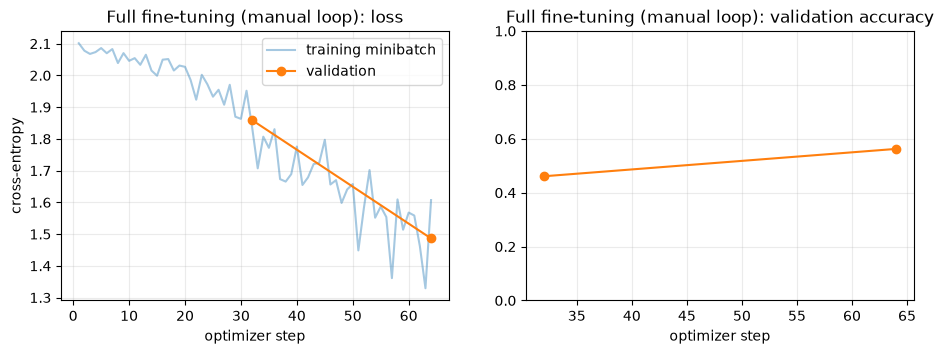

full FT (manual loop) {'val_acc': 0.562, 'trainable_params': 66959624, 'trainable_%': 100.0, 'train_time_s': 151.6}
encoder changed: True


In [93]:
full_model = load_model()
print_parameters(full_model)
encoder_before = full_model.distilbert.transformer.layer[0].attention.q_lin.weight.detach().cpu().clone()

full_history = train_classifier(full_model, train_loader, val_loader, lr=2e-5)
plot_history(full_history, "Full fine-tuning (manual loop)")
record("full FT (manual loop)", full_model, full_history["val_acc"][-1], full_history["seconds"])
# TODO: inspect the same encoder weight after full fine-tuning. Did it change?
encoder_after = full_model.distilbert.transformer.layer[0].attention.q_lin.weight.detach().cpu()
print("encoder changed:", not torch.equal(encoder_before, encoder_after))


🟧 **After full fine-tuning**

1. The cell prints whether an encoder weight changed. What does that result tell you about full fine-tuning?
3. Compare the final validation accuracy with the baseline accuracy. Did this run improve on videos the model did not train on?


🟩 **Answer**

1. **Both encoder and head can change.** The model loads with their parameters trainable; train_classifier passes every parameter with requires_grad=True to AdamW. The encoder-weight check after training should report True.
3. Compare full_history["val_acc"][-1] with baseline_acc. If the former is larger, validation accuracy improved in that run; if not, it did not. A falling training loss alone cannot answer this.


In [94]:
# Small helper used later to try the model on any text
@torch.no_grad()
def predict(model, text):
    model.eval()
    inputs = tokenizer(text, truncation=True, max_length=MAX_LENGTH, return_tensors="pt").to(device)
    probabilities = model(**inputs).logits.softmax(dim=-1)[0]
    best = probabilities.argmax().item()
    return label_to_category[best], round(probabilities[best].item(), 3)


sample = val_df.sample(1, random_state=1).iloc[0]
print(sample["text"][:300], "...")
print("true category:", sample["category"])
print("prediction:   ", predict(full_model, sample["text"]))

del full_model

Title: Mirai Nagasu describes her mindset in a triple Axel
Description: Mirai Nagasu became the first American woman to land a triple axel in the team figure skating competition at the 2018 Winter Olympics.\n\nBe Smarter. Faster. More Colorful and get the full story at http://www.usatoday.com/\n\nSu ...
true category: Sports
prediction:    ('Sports', 0.266)


## 5. Exercise 2 — Freeze the body

Set `requires_grad` so only DistilBERT's two head layers (`pre_classifier` and `classifier`) train. Reuse the same loop and data. The head has random weights, so it needs to learn even though the body is frozen.


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1428.86it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable: 596,744 / 66,959,624 (0.89%)
epoch 1: val loss=1.499  val acc=0.578  (30s)
epoch 2: val loss=1.328  val acc=0.547  (59s)


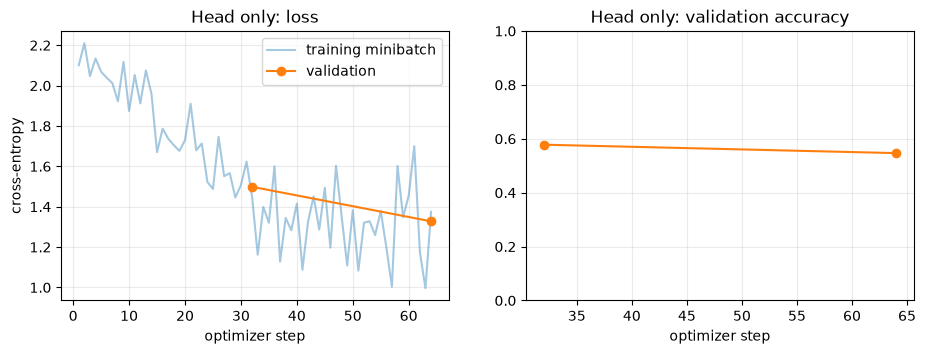

head only {'val_acc': 0.547, 'trainable_params': 596744, 'trainable_%': 0.89, 'train_time_s': 59.3}
encoder unchanged: True
head changed: True


In [95]:
head_model = load_model()
encoder_before = head_model.distilbert.transformer.layer[0].attention.q_lin.weight.detach().cpu().clone()
head_before = head_model.classifier.weight.detach().cpu().clone()

# TODO: freeze every parameter, then unfreeze those of the head
# (their names start with "pre_classifier" or "classifier")
for name, parameter in head_model.named_parameters():
    parameter.requires_grad = name.startswith(("pre_classifier", "classifier"))

print_parameters(head_model)

# A frozen body allows a much larger learning rate for the head
head_history = train_classifier(head_model, train_loader, val_loader, lr=1e-3)
plot_history(head_history, "Head only")
record("head only", head_model, head_history["val_acc"][-1], head_history["seconds"])
# TODO: inspect the encoder and classifier weights after head-only training.
encoder_after = head_model.distilbert.transformer.layer[0].attention.q_lin.weight.detach().cpu()
head_after = head_model.classifier.weight.detach().cpu()
print("encoder unchanged:", torch.equal(encoder_before, encoder_after))
print("head changed:", not torch.equal(head_before, head_after))
del head_model

🟧 **After head-only training**

1. The cell checks an encoder weight and a classifier weight. Which stayed the same, and which changed?
2. How can the model learn categories if its encoder is frozen?
3. Compare head-only and full fine-tuning in trainable parameter count and validation accuracy. What tradeoff do you see in your run?


🟩 **Answer**

1. Only pre_classifier and classifier trained. The encoder check should report unchanged=True; the classifier check should report changed=True.
2. The head can learn a mapping from the encoder's fixed text representations to the eight categories.
3. For this model, head-only training updates about **597k parameters (0.89%)**, versus about **67M** in full fine-tuning. Compare the recorded validation accuracies for the quality difference in your run. Head-only training cannot reshape the encoder's internal representations.


## 6. Exercise 3 — LoRA

Full fine-tuning learns a change to each weight matrix. **LoRA** writes the change as the product of two thin matrices:

$$W = W_0 + (\alpha/r)BA, \quad A \in \mathbb{R}^{r \times d_{in}}, \; B \in \mathbb{R}^{d_{out} \times r}.$$

The pretrained matrix $W_0$ stays frozen. We initialize $B$ to zero so the layer initially gives exactly the same output as before. With $d_{in}=d_{out}=768$ and $r=8$, compare the number of weights in $W_0$ with those in $A$ and $B$ together.

First complete a small LoRA layer and check its output. We will use the PEFT library to attach and train adapters in the full model.


In [97]:
class LoRALinear(nn.Module):
    # Wrap a frozen nn.Linear and add a trainable low-rank update.

    def __init__(self, base: nn.Linear, r=8, alpha=16, dropout=0.1):
        super().__init__()
        self.base = base
        for parameter in self.base.parameters():
            parameter.requires_grad = False
        self.scaling = alpha / r
        self.dropout = nn.Dropout(dropout)

        # TODO: create the two trainable matrices with the right shapes
        #   lora_A: (r, in_features)  -> random init (use nn.init.kaiming_uniform_(..., a=math.sqrt(5)))
        #   lora_B: (out_features, r) -> zeros
        self.lora_A = nn.Parameter(torch.empty(r, base.in_features))
        self.lora_B = nn.Parameter(torch.zeros(base.out_features, r))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

    def forward(self, x):
        # x: (..., in_features)
        # TODO: base output + scaling * B A x   (apply dropout to x on the LoRA branch only)
        lora_update = self.dropout(x) @ self.lora_A.T @ self.lora_B.T
        return self.base(x) + self.scaling * lora_update


# Sanity check on a single layer
torch.manual_seed(0)
linear = nn.Linear(768, 768)
lora_linear = LoRALinear(linear, r=8, alpha=16).eval()
x = torch.randn(2, 5, 768)
print("output shape:", tuple(lora_linear(x).shape))
print("identical to the base layer at init:", torch.allclose(lora_linear(x), linear(x)))
print("LoRA parameters:", lora_linear.lora_A.numel() + lora_linear.lora_B.numel())

output shape: (2, 5, 768)
identical to the base layer at init: True
LoRA parameters: 12288


### Train LoRA with PEFT

Attach rank-8 adapters to the query and value projections in each attention block. The classification head also needs training. Reuse the same loop as before; only its list of trainable parameters changes.

🟧 **Before training LoRA**

1. The small LoRA layer initially gives the same output as its base layer. Which initialization choice makes that happen?
2. If the rank changes from 8 to 16, what happens to the number of LoRA weights in one 768 × 768 layer?
3. Does a larger rank guarantee better validation accuracy?


🟩 **Answer**

The LoRA branch adds (alpha/r)BAx. When B starts at zero, BAx is zero for every input, so the wrapped layer initially matches the frozen base layer.

For one 768-by-768 projection, rank 8 uses 8×768 + 768×8 = **12,288** LoRA weights. Rank 16 uses **24,576**: twice as many adapter weights. The fixed base and head do not double, and a higher rank does not guarantee higher validation accuracy.


In [98]:
from peft import LoraConfig, TaskType, get_peft_model

# TODO: build a LoraConfig identical to our implementation
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],
    modules_to_save=["pre_classifier", "classifier"],
)

peft_model = get_peft_model(load_model(), lora_config)
peft_model.print_trainable_parameters()
print(peft_model.base_model.model.distilbert.transformer.layer[0].attention.q_lin)
# TODO: list the trainable tensors. Find the LoRA matrices and saved head layers.
trainable_names = [name for name, parameter in peft_model.named_parameters() if parameter.requires_grad]
print("LoRA tensors:", [name for name in trainable_names if "lora_" in name][:4])
print("saved head tensors:", [name for name in trainable_names if "modules_to_save" in name])


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1158.09it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 744,200 || all params: 67,703,824 || trainable%: 1.0992
lora.Linear(
  (base_layer): Linear(in_features=768, out_features=768, bias=True)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.1, inplace=False)
  )
  (lora_A): ModuleDict(
    (default): Linear(in_features=768, out_features=8, bias=False)
  )
  (lora_B): ModuleDict(
    (default): Linear(in_features=8, out_features=768, bias=False)
  )
  (lora_embedding_A): ParameterDict()
  (lora_embedding_B): ParameterDict()
  (lora_magnitude_vector): ModuleDict()
)
LoRA tensors: ['base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_A.default.weight', 'base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_B.default.weight', 'base_model.model.distilbert.transformer.layer.0.attention.v_lin.lora_A.default.weight', 'base_model.model.distilbert.transformer.layer.0.attention.v_lin.lora_B.default.weight']
saved head tensors: ['base_model.model.pre_classifier.modules_to_save.default.weight',

epoch 1: val loss=1.286  val acc=0.539  (50s)
epoch 2: val loss=1.286  val acc=0.570  (105s)


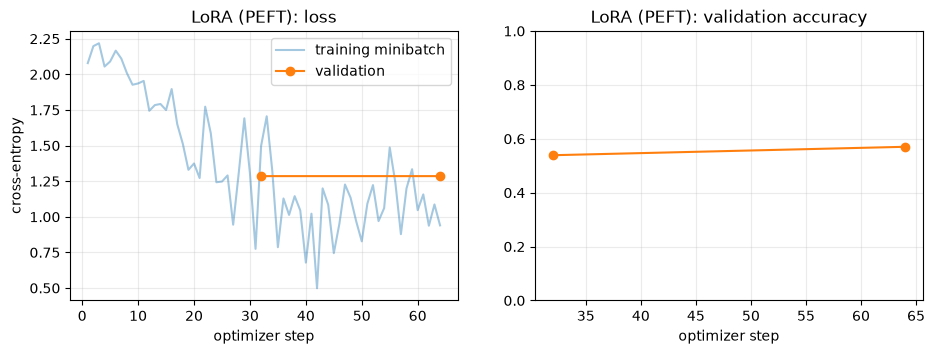

LoRA {'val_acc': 0.57, 'trainable_params': 744200, 'trainable_%': 1.1, 'train_time_s': 104.8}


In [99]:
peft_history = train_classifier(peft_model, train_loader, val_loader, lr=1e-3)
plot_history(peft_history, "LoRA (PEFT)")
record("LoRA", peft_model, peft_history["val_acc"][-1], peft_history["seconds"])


### Adapter size

PEFT saves the adapter and the task head. The pretrained base model can be shared across tasks. Run the next cell to compare the saved adapter with the approximate float32 size of a full model.


In [100]:
peft_model.save_pretrained("outputs/lora_adapter")
adapter_mb = sum(f.stat().st_size for f in Path("outputs/lora_adapter").glob("*")) / 1e6
_, total = count_parameters(peft_model)
print(f"adapter on disk: {adapter_mb:.1f} MB")
print(f"full model in float32 would be about: {total * 4 / 1e6:.0f} MB")
print(sorted(f.name for f in Path("outputs/lora_adapter").glob("*")))

adapter on disk: 3.0 MB
full model in float32 would be about: 271 MB
['README.md', 'adapter_config.json', 'adapter_model.safetensors']


🟧 **After saving the adapter**

1. Look at the files printed above. Did we save another full copy of DistilBERT, or just the adapter and task head?
2. What else must be available to use this adapter for predictions?
3. If 50 tasks use the same base model, which files can they share?


🟩 **Answer**

The saved folder contains adapter configuration and trained adapter weights, including the task-head layers listed in modules_to_save. It does not contain another copy of the full pretrained encoder.

For inference elsewhere, load the same base model and tokenizer, then attach the adapter. Keep the category-ID mapping to turn the predicted ID into a category name. Sharing one base checkpoint plus small per-task adapters uses less storage than saving a full model for every task.


In [101]:
print(predict(peft_model, "Title: Top 10 football goals\nDescription: Match highlights"))
print(predict(peft_model, "Title: Easy makeup tutorial\nDescription: Five-minute beauty tips"))
# Try one title of your own.
del peft_model


('Sports', 0.753)
('Howto & Style', 0.572)


## 7. Compare the methods

Use the table and plot to make a claim supported by the results you actually measured. Small validation sets and random initialization can change the ordering between methods.


In [102]:
summary = pd.DataFrame(results).T
summary

,val_acc,trainable_params,trainable_%,train_time_s
full FT (manual loop),0.562,66959624.0,100.00,151.6
head only,0.547,596744.0,0.89,59.3
LoRA,0.570,744200.0,1.10,104.8


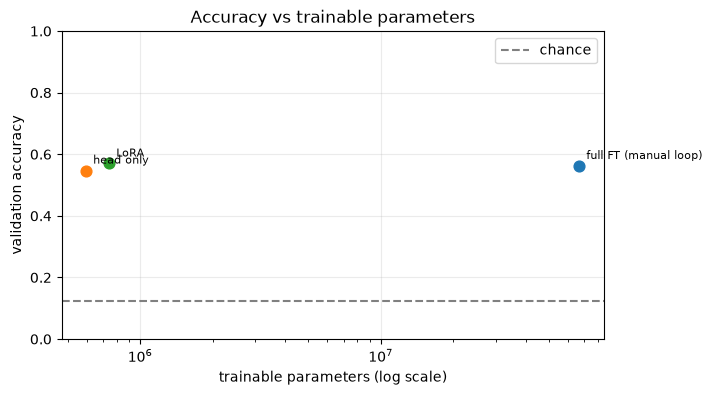

In [103]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, row in summary.iterrows():
    ax.scatter(row["trainable_params"], row["val_acc"], s=60)
    ax.annotate(name, (row["trainable_params"], row["val_acc"]), textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.axhline(1 / NUM_CATEGORIES, color="grey", linestyle="--", label="chance")
ax.set(xscale="log", xlabel="trainable parameters (log scale)", ylabel="validation accuracy",
       title="Accuracy vs trainable parameters", ylim=(0, 1))
ax.grid(alpha=0.25)
ax.legend()
plt.show()

🟧 **Choose a fine-tuning method**

Based on your validation results, which method would you choose for this dataset? Give one reason.

**Takeaway:** The training loop is familiar; the fine-tuning method determines where the task-specific learning happens and how much must be stored.


🟩 **Answer**

1. Full fine-tuning updates the encoder and head. Head-only training updates the two head layers. LoRA trains added matrices in selected query and value projections, plus the head; the original encoder weights stay frozen.
2. LoRA adds its task-specific update *inside* attention blocks. Head-only training can only use the final representation produced by the frozen encoder.
3. Keep the pretrained base model once. Save a separate adapter and task head for each task. Head-only training could save an even smaller task head for each task.
4. There is no universal winner. Choose the smallest method whose validation accuracy is good enough in your results. If the difference is small, repeat the experiment or use more validation data before claiming one method is better.


## Optional — Repeat full fine-tuning with Trainer

The Hugging Face Trainer handles the loop, data loaders, and evaluation. This is an extra run on the same task. We choose a constant learning rate and disable gradient clipping to make its setup closer to our manual loop. Small differences can remain because batches and random state differ.


In [ ]:
from transformers import Trainer, TrainingArguments


def compute_metrics(eval_prediction):
    # eval_prediction.predictions: numpy array of logits (N, K)
    # eval_prediction.label_ids:  numpy array of labels (N,)
    predictions = eval_prediction.predictions.argmax(axis=-1)
    return {"accuracy": (predictions == eval_prediction.label_ids).mean().item()}


def make_training_args(output_dir, lr):
    return TrainingArguments(
        output_dir=output_dir,
        learning_rate=lr,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=2 * BATCH_SIZE,
        num_train_epochs=EPOCHS,
        weight_decay=0.0,
        lr_scheduler_type="constant",   # like our loop
        max_grad_norm=0.0,              # 0 disables gradient clipping
        eval_strategy="epoch",
        logging_steps=10,
        save_strategy="no",             # do not write checkpoints to disk
        report_to="none",               # no wandb / tensorboard
        seed=SEED,
    )

In [ ]:
hf_model = load_model()

trainer = Trainer(
    model=hf_model,
    args=make_training_args("outputs/full_trainer", lr=2e-5),
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

started = time.perf_counter()
trainer.train()
trainer_seconds = time.perf_counter() - started

trainer_metrics = trainer.evaluate()
print(trainer_metrics)
record("full FT (Trainer)", hf_model, trainer_metrics["eval_accuracy"], trainer_seconds)

🟧 **Trainer and PEFT**

1. The optional Trainer run loads a fresh model. Which weights will it update?
2. What would you change before giving a model to Trainer for head-only training or LoRA?


🟩 **Answer**

1. The fresh model has trainable encoder and head weights, so Trainer performs full fine-tuning.
2. For head-only training, freeze the encoder before constructing Trainer. For LoRA, wrap the base model with get_peft_model and a LoraConfig first. Trainer runs the update loop; the model's trainable-parameter settings determine which weights change.
